In [1]:
#use a Generative Adversarial Network (GAN) with LSTM, a type of Recurrent Neural Network, as generator, a
#and a Convolutional Neural Network, CNN, as a discriminator. We use LSTM for the obvious reason that we are 
#trying to predict time series data. 

#https://github.com/borisbanushev/stockpredictionai

In [71]:
import warnings
warnings.filterwarnings("ignore")

from utils import *

import time
import numpy as np

#Torch deep learning framework
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable

import datetime
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA

import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.metrics import accuracy_score

import yfinance as yf
import datetime as dt
import pandas as pd

In [4]:
device = torch.device("cpu")
torch.manual_seed(1719)

In [5]:
def parser(x):
    return datetime.datetime.strptime(x,'%Y-%m-%d')

In [59]:
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=3500)

symbol = 'GS'

dataset_ex_df=yf.download(symbol,start=startDate,end=endDate,interval="1d")
dataset_ex_df=dataset_ex_df['Adj Close'].to_frame()

[*********************100%%**********************]  1 of 1 completed


In [60]:
dataset_ex_df = dataset_ex_df.rename(columns={'Adj Close': symbol})
dataset_ex_df = dataset_ex_df.reset_index(drop=False)
print(dataset_ex_df.head())

        Date          GS
0 2014-07-07  140.160461
1 2014-07-08  137.762848
2 2014-07-09  137.562317
3 2014-07-10  136.518143
4 2014-07-11  137.670990


In [61]:
print('There are {} number of days in the dataset.'.format(dataset_ex_df.shape[0]))

There are 2412 number of days in the dataset.


In [62]:
#Let's visualize the stock for the last nine years. The dashed vertical line represents the separation 
#between training and test data.

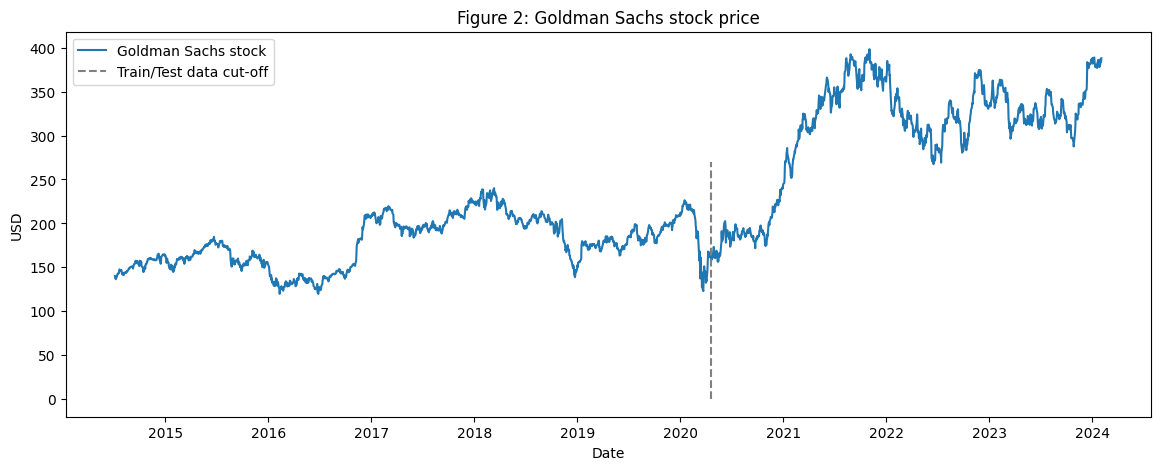

In [63]:
plt.figure(figsize=(14, 5), dpi=100)
plt.plot(dataset_ex_df['Date'], dataset_ex_df['GS'], label='Goldman Sachs stock')
plt.vlines(datetime.date(2020,4, 20), 0, 270, linestyles='--', colors='gray', label='Train/Test data cut-off')
plt.xlabel('Date')
plt.ylabel('USD')
plt.title('Figure 2: Goldman Sachs stock price')
plt.legend()
plt.show()

In [64]:
num_training_days = int(dataset_ex_df.shape[0]*.7)
print('Number of training days: {}. Number of test days: {}.'.format(num_training_days, \
                                                                    dataset_ex_df.shape[0]-num_training_days))


Number of training days: 1688. Number of test days: 724.


In [65]:
#3.1 Correlated assets

In [90]:
#Create Technical Indicators
def get_technical_indicators(dataset):
    # Create 7 and 21 days Moving Average
    dataset['ma7'] = dataset[symbol].rolling(window=7).mean()
    dataset['ma21'] = dataset[symbol].rolling(window=21).mean()
    
    # Create MACD
    dataset['26ema'] = dataset[symbol].ewm(span=26).mean()
    dataset['12ema'] = dataset[symbol].ewm(span=12).mean()
    dataset['MACD'] = (dataset['12ema']-dataset['26ema'])

    # Create Bollinger Bands
    dataset['20sd'] = dataset[symbol].rolling(window=20).std()
    dataset['upper_band'] = dataset['ma21'] + (dataset['20sd']*2)
    dataset['lower_band'] = dataset['ma21'] - (dataset['20sd']*2)
    
    # Create Exponential moving average
    dataset['ema'] = dataset[symbol].ewm(com=0.5).mean()
    
    # Create Momentum
    dataset['momentum'] = dataset[symbol]-1

     # Create log_Momentum
    dataset['log_momentum'] = np.log(dataset[symbol]-1)
    
    return dataset

In [91]:
dataset_TI_df = get_technical_indicators(dataset_ex_df)
dataset_TI_df=dataset_TI_df.dropna()
dataset_TI_df = dataset_TI_df.reset_index(drop=True)


In [92]:
dataset_TI_df.head()

,Date,GS,ma7,ma21,26ema,12ema,MACD,20sd,upper_band,lower_band,ema,momentum,log_momentum
0,2014-08-04,143.426788,145.292049,142.854718,143.904471,144.493531,0.589060,3.651299,150.157315,135.552121,143.357184,142.426788,4.958828
1,2014-08-05,141.530472,144.578406,142.919957,143.688982,144.025822,0.336840,3.459611,149.839179,136.000734,142.139376,140.530472,4.945424
2,2014-08-06,141.797760,143.837306,143.112095,143.520134,143.675531,0.155397,3.219048,149.550191,136.674000,141.911632,140.797760,4.947325
3,2014-08-07,141.263107,143.068747,143.288324,143.321645,143.297530,-0.024116,2.838296,148.964916,137.611731,141.479282,140.263107,4.943520
4,2014-08-08,143.902908,142.651051,143.639979,143.372064,143.392117,0.020053,2.467951,148.575881,138.704077,143.095033,142.902908,4.962165


In [93]:
#technical indicators (including MACD, Bollinger bands, etc) for every trading day.In total 12 technical indicators.
#visualize the last 400 days of these indicators.

In [94]:
def plot_technical_indicators(dataset, last_days):
    plt.figure(figsize=(16, 10), dpi=100)
    shape_0 = dataset.shape[0]
    xmacd_ = shape_0-last_days
    
    dataset = dataset.iloc[-last_days:, :]
    x_ = range(3, dataset.shape[0])
    x_ =list(dataset.index)
    
    # Plot first subplot
    plt.subplot(2, 1, 1)
    plt.plot(dataset['ma7'],label='MA 7', color='g',linestyle='--')
    plt.plot(dataset[symbol],label='Closing Price', color='b')
    plt.plot(dataset['ma21'],label='MA 21', color='r',linestyle='--')
    plt.plot(dataset['upper_band'],label='Upper Band', color='c')
    plt.plot(dataset['lower_band'],label='Lower Band', color='c')
    plt.fill_between(x_, dataset['lower_band'], dataset['upper_band'], alpha=0.35)
    plt.title('Technical indicators for Goldman Sachs - last {} days.'.format(last_days))
    plt.ylabel('USD')
    plt.legend()

    # Plot second subplot
    plt.subplot(2, 1, 2)
    plt.title('MACD')
    plt.plot(dataset['MACD'],label='MACD', linestyle='-.')
    plt.hlines(15, xmacd_, shape_0, colors='g', linestyles='--')
    plt.hlines(-15, xmacd_, shape_0, colors='g', linestyles='--')
    plt.plot(dataset['log_momentum'],label='Momentum', color='b',linestyle='-')

    plt.legend()
    plt.show()

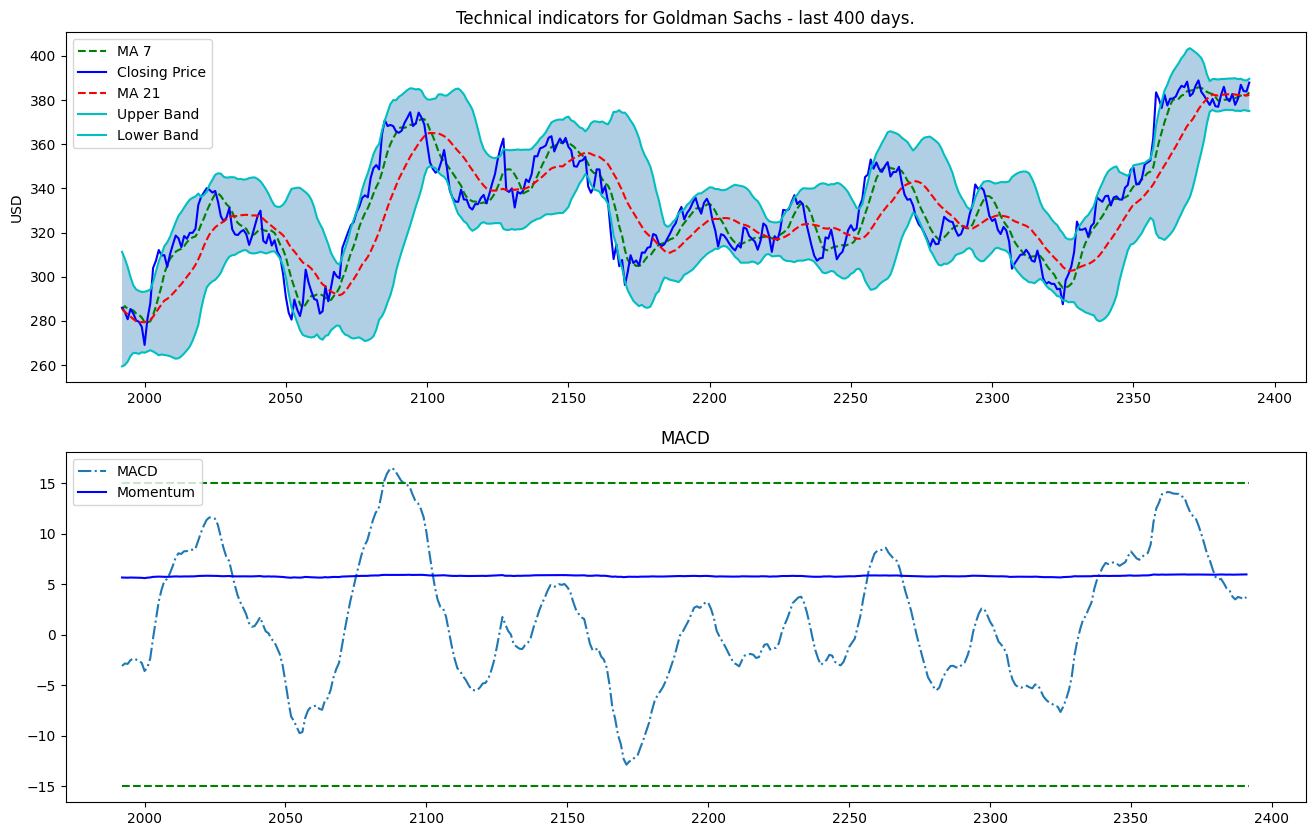

In [95]:
plot_technical_indicators(dataset_TI_df, 400)

In [96]:
#3.3 Fourier transforms for trend analysis

# use Fourier transforms to extract global and local trends in the GS stock, and to also denoise it a little.

In [97]:
data_FT = dataset_ex_df[['Date', 'GS']]

In [98]:
close_fft = np.fft.fft(np.asarray(data_FT['GS'].tolist()))
fft_df = pd.DataFrame({'fft':close_fft})
fft_df['absolute'] = fft_df['fft'].apply(lambda x: np.abs(x))
fft_df['angle'] = fft_df['fft'].apply(lambda x: np.angle(x))

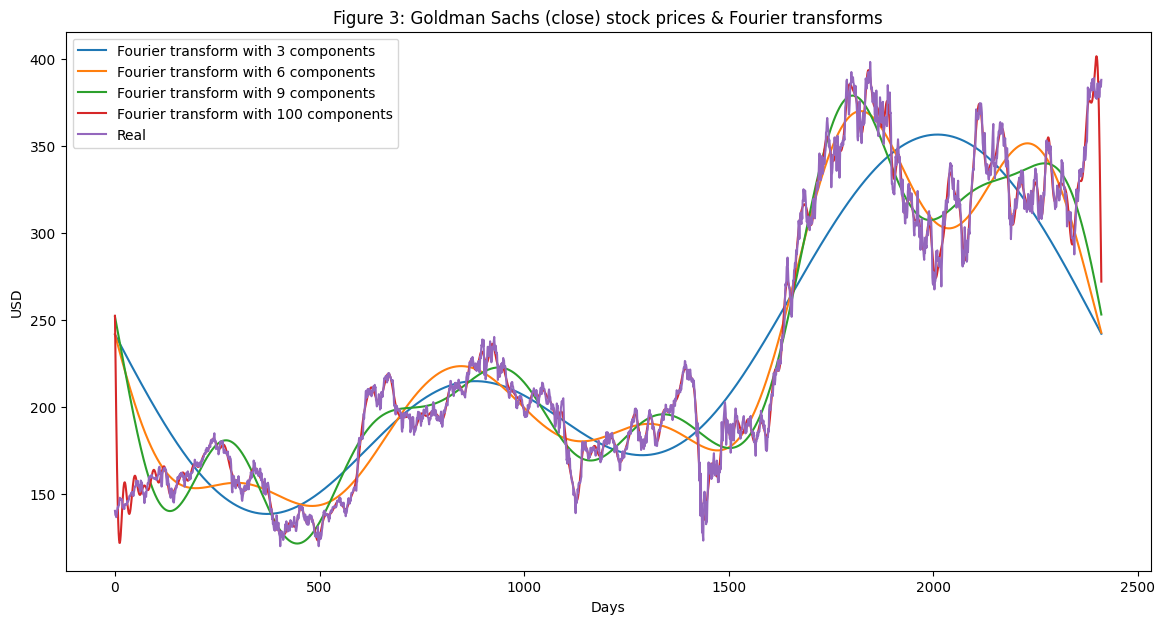

In [99]:
plt.figure(figsize=(14, 7), dpi=100)
fft_list = np.asarray(fft_df['fft'].tolist())
for num_ in [3, 6, 9, 100]:
    fft_list_m10= np.copy(fft_list); fft_list_m10[num_:-num_]=0
    plt.plot(np.fft.ifft(fft_list_m10), label='Fourier transform with {} components'.format(num_))
plt.plot(data_FT['GS'],  label='Real')
plt.xlabel('Days')
plt.ylabel('USD')
plt.title('Figure 3: Goldman Sachs (close) stock prices & Fourier transforms')
plt.legend()
plt.show()

 the more components from the Fourier transform we use the closer the approximation function is to the real stock price (the 100 components transform is almost identical to the original function - the red and the purple lines almost overlap). We use Fourier transforms for the purpose of extracting long- and short-term trends so we will use the transforms with 3, 6, and 9 components. You can infer that the transform with 3 components serves as the long term trend.

Another technique used to denoise data is call wavelets. Wavelets and Fourier transform gave similar results so we will only use Fourier transforms.

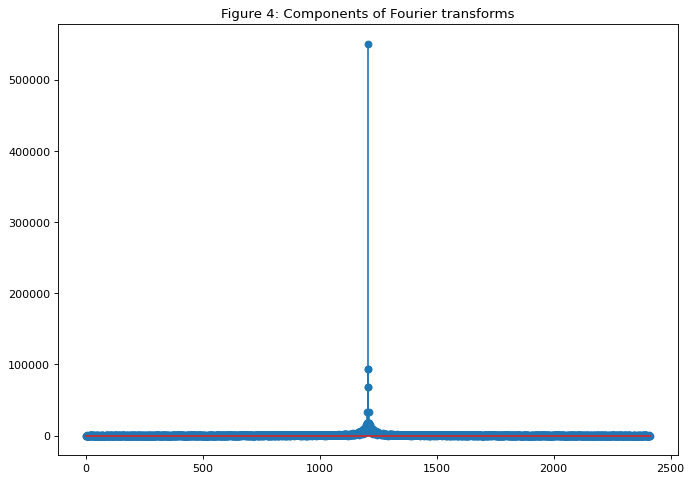

In [100]:
from collections import deque
items = deque(np.asarray(fft_df['absolute'].tolist()))
items.rotate(int(np.floor(len(fft_df)/2)))
plt.figure(figsize=(10, 7), dpi=80)
plt.stem(items)
plt.title('Figure 4: Components of Fourier transforms')
plt.show()

3.5. ARIMA as a feature

ARIMA is a technique for predicting time series data. We will show how to use it, and althouth ARIMA will not serve as our final prediction, we will use it as a technique to denoise the stock a little and to (possibly) extract some new patters or features.

In [110]:
from statsmodels.tsa.arima.model import ARIMA
from pandas import DataFrame

series = data_FT['GS']
model = ARIMA(series, order=(5, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                     GS   No. Observations:                 2412
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6773.689
Date:                Mon, 05 Feb 2024   AIC                          13559.377
Time:                        10:35:41   BIC                          13594.104
Sample:                             0   HQIC                         13572.008
                               - 2412                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0249      0.013      1.945      0.052      -0.000       0.050
ar.L2          0.0344      0.015      2.354      0.019       0.006       0.063
ar.L3         -0.0065      0.014     -0.452      0.6

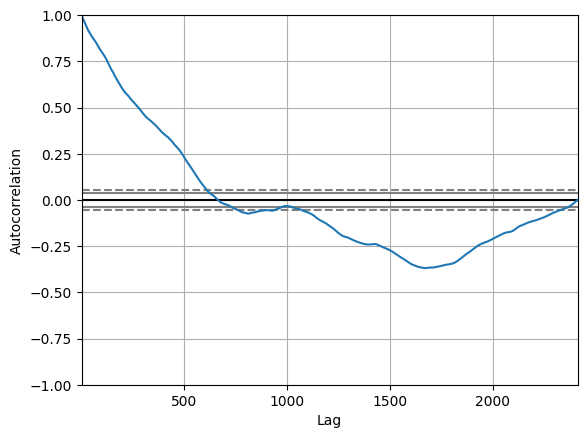

<Figure size 800x560 with 0 Axes>

In [112]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(series)
plt.figure(figsize=(10, 7), dpi=80)
plt.show() 

In [113]:
from sklearn.metrics import mean_squared_error

X = series.values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)

In [114]:
error = mean_squared_error(test, predictions)
print('Test MSE: %.3f' % error)

Test MSE: 28.602


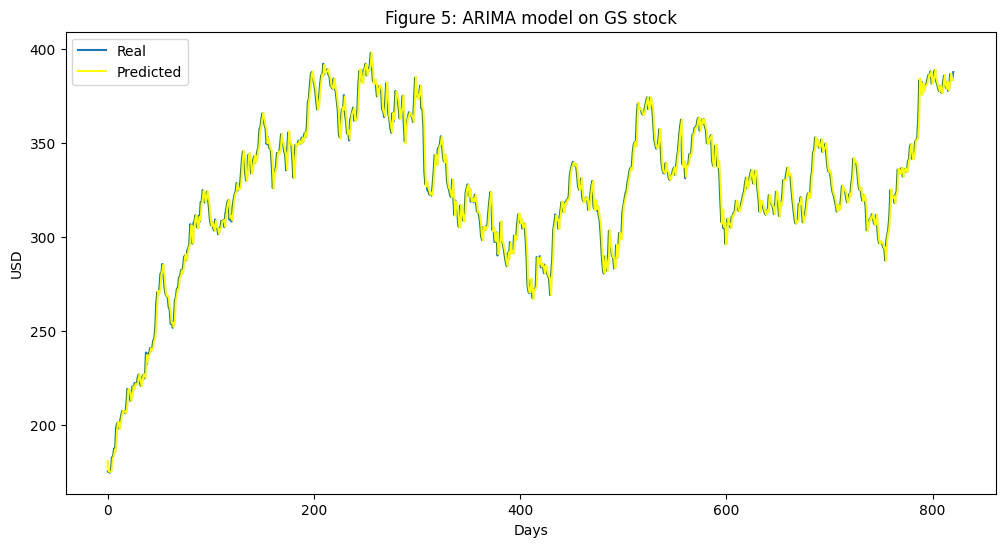

In [116]:
# Plot the predicted (from ARIMA) and real prices

plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test, label='Real')
plt.plot(predictions, color='yellow', label='Predicted')
plt.xlabel('Days')
plt.ylabel('USD')
plt.title('Figure 5: ARIMA model on GS stock')
plt.legend()
plt.show()

As we can see from Figure 5 ARIMA gives a very good approximation of the real stock price. We will use the predicted price through ARIMA as an input feature into the LSTM because, as we mentioned before, we want to capture as many features and patterns about Goldman Sachs as possible. We go test MSE (mean squared error), which by itself is not a bad result (considering we do have a lot of test data), but still we will only use it as a feature in the LSTM.

In [117]:
#3.6 Statistical checks

#Ensuring that the data has good quality is very important for out models. 
#In order to make sure our data is suitable we will perform a couple of simple checks 
#in order to ensure that the results we achieve and observe are indeed real, rather 
#than compromised due to the fact that the underlying data distribution suffers from fundamental errors.

#3.6.1. Heteroskedasticity, multicollinearity, serial correlation

#Conditional Heteroskedasticity occurs when the error terms (the difference between a predicted value by a 
#regression and the real value) are dependent on the data - for example, the error terms grow when the data 
#point (along the x-axis) grow.

#Multicollinearity is when error terms (also called residuals) depend on each other.

#Serial correlation is when one data (feature) is a formula (or completely depends) of another feature.

In [130]:
import xgboost as xgb
import helper

dataset_TI_df = dataset_TI_df.rename(columns={'GS': 'Close'})
print('The shape of the dataset is:', dataset_TI_df.shape)
print(dataset_TI_df.columns)

The shape of the dataset is: (2392, 13)
Index(['Date', 'Close', 'ma7', 'ma21', '26ema', '12ema', 'MACD', '20sd',
       'upper_band', 'lower_band', 'ema', 'momentum', 'log_momentum'],
      dtype='object')


In [131]:
# Get training and test data
(X_train_FI, y_train_FI), (X_test_FI, y_test_FI) = helper.get_feature_importance_data(dataset_TI_df)

In [132]:
regressor = xgb.XGBRegressor(gamma=0.0,n_estimators=150,base_score=0.7,colsample_bytree=1,learning_rate=0.05)

In [139]:
xgbModel = regressor.fit(X_train_FI,y_train_FI, \
                         eval_set = [(X_train_FI, y_train_FI), (X_test_FI, y_test_FI)], \
                         verbose=False)

In [140]:
eval_result = regressor.evals_result()

In [141]:
training_rounds = range(len(eval_result['validation_0']['rmse']))

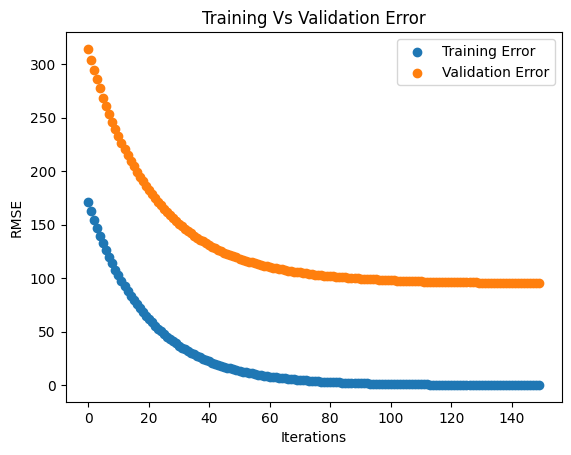

In [142]:
plt.scatter(x=training_rounds,y=eval_result['validation_0']['rmse'],label='Training Error')
plt.scatter(x=training_rounds,y=eval_result['validation_1']['rmse'],label='Validation Error')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('Training Vs Validation Error')
plt.legend()
plt.show()

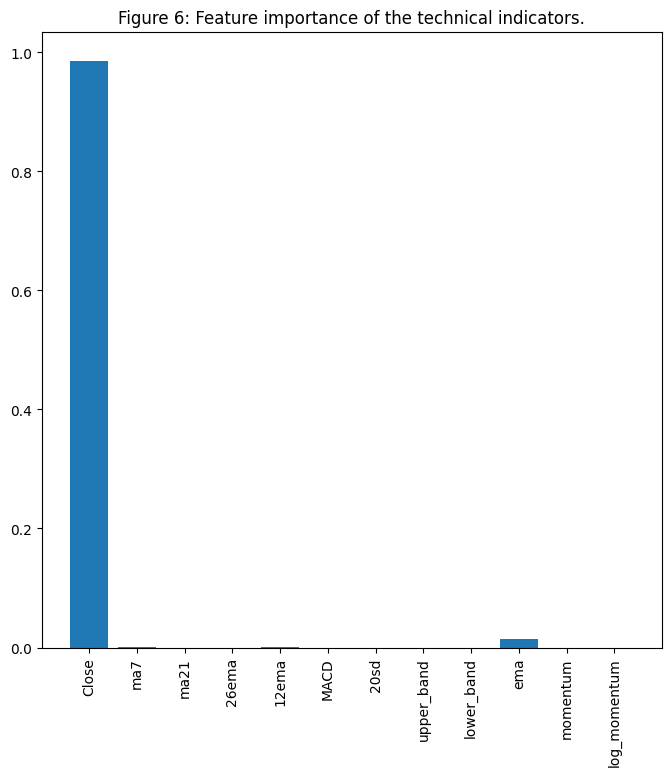

In [144]:
fig = plt.figure(figsize=(8,8))
plt.xticks(rotation='vertical')
plt.bar([i for i in range(len(xgbModel.feature_importances_))], xgbModel.feature_importances_.tolist(), tick_label=X_test_FI.columns)
plt.title('Figure 6: Feature importance of the technical indicators.')
plt.show()

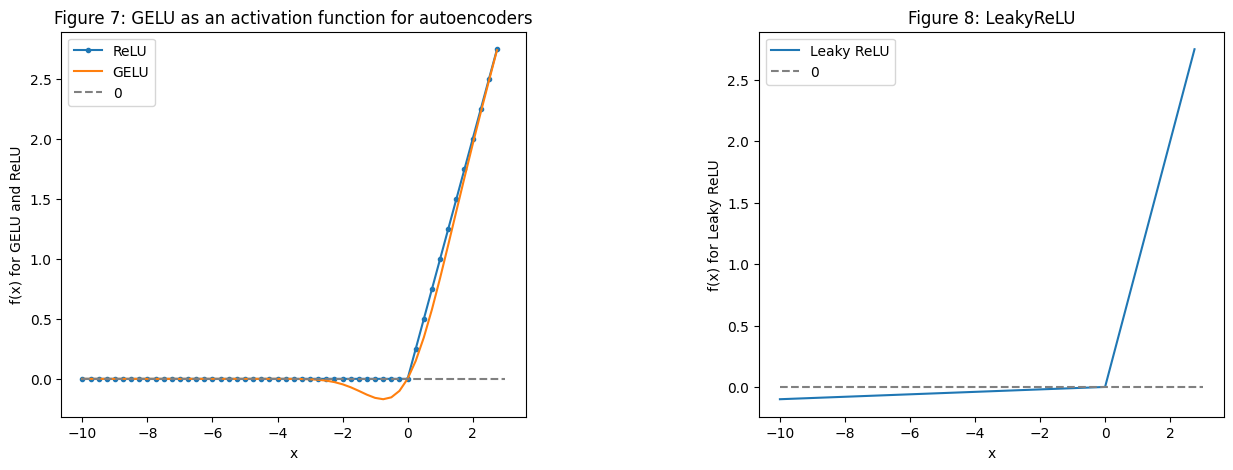

In [138]:
plt.figure(figsize=(15, 5))
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=.5, hspace=None)

ranges_ = (-10, 3, .25)

plt.subplot(1, 2, 1)
plt.plot([i for i in np.arange(*ranges_)], [helper.relu(i) for i in np.arange(*ranges_)], label='ReLU', marker='.')
plt.plot([i for i in np.arange(*ranges_)], [helper.gelu(i) for i in np.arange(*ranges_)], label='GELU')
plt.hlines(0, -10, 3, colors='gray', linestyles='--', label='0')
plt.title('Figure 7: GELU as an activation function for autoencoders')
plt.ylabel('f(x) for GELU and ReLU')
plt.xlabel('x')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([i for i in np.arange(*ranges_)], [helper.lrelu(i) for i in np.arange(*ranges_)], label='Leaky ReLU')
plt.hlines(0, -10, 3, colors='gray', linestyles='--', label='0')
plt.ylabel('f(x) for Leaky ReLU')
plt.xlabel('x')
plt.title('Figure 8: LeakyReLU')
plt.legend()

plt.show()